In [2]:
# =============================================================================
# Libraries
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Modeling
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (roc_auc_score, roc_curve, classification_report, 
                             confusion_matrix, precision_recall_curve)

# Imbalance handling
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

# Display settings
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

# Plot styling (version-safe)
try:
    # Try newer seaborn style
    plt.style.use('seaborn-v0_8')
except:
    try:
        # Try older seaborn style
        plt.style.use('seaborn-darkgrid')
    except:
        # Fall back to default
        sns.set_style("darkgrid")
        print("Using seaborn style configuration")

# Set default figure size
plt.rcParams['figure.figsize'] = (10, 6)

print("✓ All libraries imported successfully!")
print(f"✓ Pandas version: {pd.__version__}")
print(f"✓ NumPy version: {np.__version__}")
print(f"✓ Matplotlib version: {plt.matplotlib.__version__}")
print(f"✓ Seaborn version: {sns.__version__}")

RuntimeError: module was compiled against NumPy C-API version 0x10 (NumPy 1.23) but the running NumPy has C-API version 0xe. Check the section C-API incompatibility at the Troubleshooting ImportError section at https://numpy.org/devdocs/user/troubleshooting-importerror.html#c-api-incompatibility for indications on how to solve this problem.

✓ All libraries imported successfully!
✓ Pandas version: 2.0.3
✓ NumPy version: 1.21.6
✓ Matplotlib version: 3.5.1
✓ Seaborn version: 0.11.2


In [3]:
# =============================================================================
# DATA LOADING
# =============================================================================
# Download from: https://www.kaggle.com/c/home-credit-default-risk/data
# We'll work primarily with application_train.csv (main dataset)

# Load main application data
app_train = pd.read_csv('application_train.csv')
app_test = pd.read_csv('application_test.csv')

print(f"Training data shape: {app_train.shape}")
print(f"Test data shape: {app_test.shape}")
print(f"\nTarget distribution:")
print(app_train['TARGET'].value_counts(normalize=True))

Training data shape: (307511, 122)
Test data shape: (48744, 121)

Target distribution:
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64


In [4]:
# =============================================================================
# STEP 1: Understand Data Types
# WHY: Different preprocessing for numerical vs categorical features
# =============================================================================
print("Data Types Summary:")
print(app_train.dtypes.value_counts())

# Identify feature types
numeric_features = app_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = app_train.select_dtypes(include=['object']).columns.tolist()

# Remove TARGET from numeric features
numeric_features.remove('TARGET')
numeric_features.remove('SK_ID_CURR')  # Customer ID, not a feature

print(f"\nNumeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")
print(f"\nFirst 5 categorical features: {categorical_features[:5]}")

Data Types Summary:
float64    65
int64      41
object     16
Name: count, dtype: int64

Numeric features: 104
Categorical features: 16

First 5 categorical features: ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE']


Top 10 features with missing values:
                                           feature  missing_count  \
COMMONAREA_MEDI                    COMMONAREA_MEDI         214865   
COMMONAREA_AVG                      COMMONAREA_AVG         214865   
COMMONAREA_MODE                    COMMONAREA_MODE         214865   
NONLIVINGAPARTMENTS_MEDI  NONLIVINGAPARTMENTS_MEDI         213514   
NONLIVINGAPARTMENTS_MODE  NONLIVINGAPARTMENTS_MODE         213514   
NONLIVINGAPARTMENTS_AVG    NONLIVINGAPARTMENTS_AVG         213514   
FONDKAPREMONT_MODE              FONDKAPREMONT_MODE         210295   
LIVINGAPARTMENTS_MODE        LIVINGAPARTMENTS_MODE         210199   
LIVINGAPARTMENTS_MEDI        LIVINGAPARTMENTS_MEDI         210199   
LIVINGAPARTMENTS_AVG          LIVINGAPARTMENTS_AVG         210199   

                          missing_pct    dtype  
COMMONAREA_MEDI             69.872297  float64  
COMMONAREA_AVG              69.872297  float64  
COMMONAREA_MODE             69.872297  float64  
NONLIVI

<Figure size 1200x600 with 0 Axes>

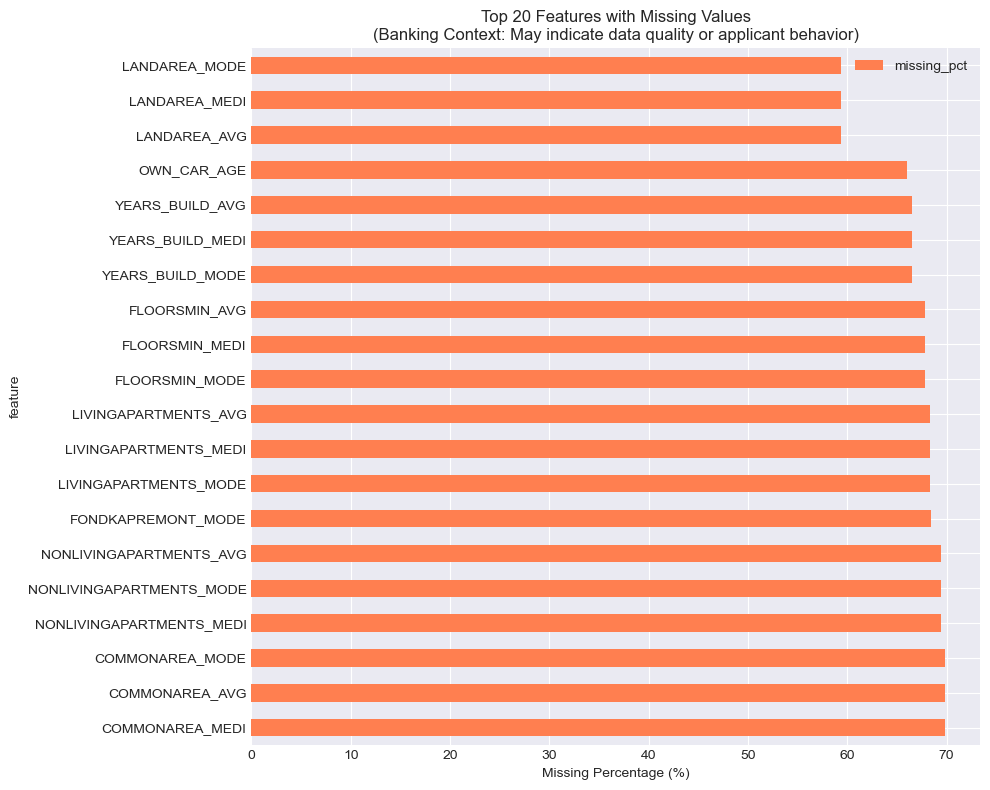

In [5]:
# =============================================================================
# STEP 2: Missing Value Analysis
# WHY: Banking context - missing values have business meaning
# - Missing employment = unemployed (higher risk)
# - Missing building info = temporary address (higher risk)
# =============================================================================
def analyze_missing_values(df):
    """Comprehensive missing value analysis"""
    missing = pd.DataFrame({
        'feature': df.columns,
        'missing_count': df.isnull().sum(),
        'missing_pct': (df.isnull().sum() / len(df)) * 100,
        'dtype': df.dtypes
    })
    missing = missing[missing['missing_count'] > 0].sort_values('missing_pct', ascending=False)
    return missing

missing_summary = analyze_missing_values(app_train)
print("Top 10 features with missing values:")
print(missing_summary.head(10))

# Visualize missing patterns
plt.figure(figsize=(12, 6))
missing_summary.head(20).plot(x='feature', y='missing_pct', kind='barh', 
                              color='coral', figsize=(10, 8))
plt.xlabel('Missing Percentage (%)')
plt.title('Top 20 Features with Missing Values\n(Banking Context: May indicate data quality or applicant behavior)')
plt.tight_layout()
plt.show()

ANALYZING KEY RISK INDICATORS


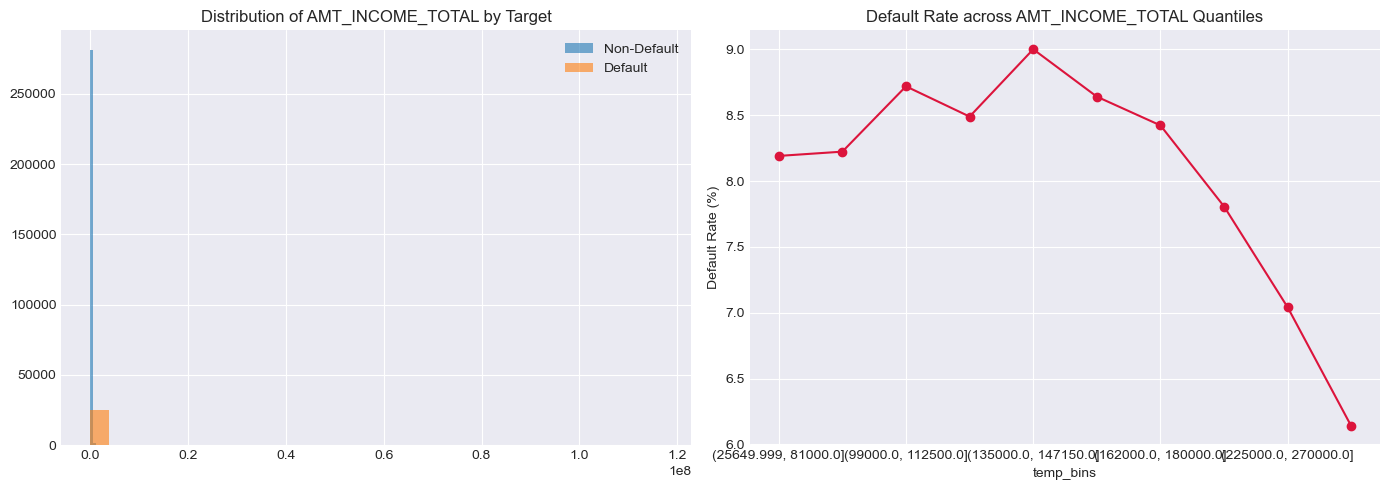

In [6]:
# =============================================================================
# STEP 3: Analyze Target Distribution by Key Features
# WHY: Understand which customer segments have higher default rates
# =============================================================================

# Helper function for target analysis
def plot_target_analysis(feature, df, figsize=(14, 5)):
    """
    Creates two plots:
    1. Distribution of feature by target
    2. Default rate by feature category
    """
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    # Plot 1: Distribution
    if df[feature].dtype == 'object':
        # Categorical
        df.groupby([feature, 'TARGET']).size().unstack().plot(kind='bar', ax=axes[0], 
                                                               color=['skyblue', 'salmon'])
        axes[0].set_title(f'Distribution of {feature} by Target')
        axes[0].set_ylabel('Count')
        
        # Plot 2: Default rate
        default_rate = df.groupby(feature)['TARGET'].mean() * 100
        default_rate.plot(kind='bar', ax=axes[1], color='crimson')
        axes[1].axhline(y=df['TARGET'].mean()*100, color='blue', linestyle='--', 
                       label=f'Overall Default Rate: {df["TARGET"].mean()*100:.2f}%')
        axes[1].set_title(f'Default Rate by {feature}')
        axes[1].set_ylabel('Default Rate (%)')
        axes[1].legend()
    else:
        # Numerical - use bins
        for target in [0, 1]:
            df[df['TARGET'] == target][feature].hist(bins=30, alpha=0.6, 
                                                      label=f'Target {target}', ax=axes[0])
        axes[0].set_title(f'Distribution of {feature} by Target')
        axes[0].legend(['Non-Default', 'Default'])
        
        # Binned default rate
        df['temp_bins'] = pd.qcut(df[feature], q=10, duplicates='drop')
        default_rate = df.groupby('temp_bins')['TARGET'].mean() * 100
        default_rate.plot(kind='line', ax=axes[1], color='crimson', marker='o')
        axes[1].set_title(f'Default Rate across {feature} Quantiles')
        axes[1].set_ylabel('Default Rate (%)')
        df.drop('temp_bins', axis=1, inplace=True)
    
    plt.tight_layout()
    plt.show()

# Analyze key features
print("=" * 80)
print("ANALYZING KEY RISK INDICATORS")
print("=" * 80)

# 1. Income
plot_target_analysis('AMT_INCOME_TOTAL', app_train)

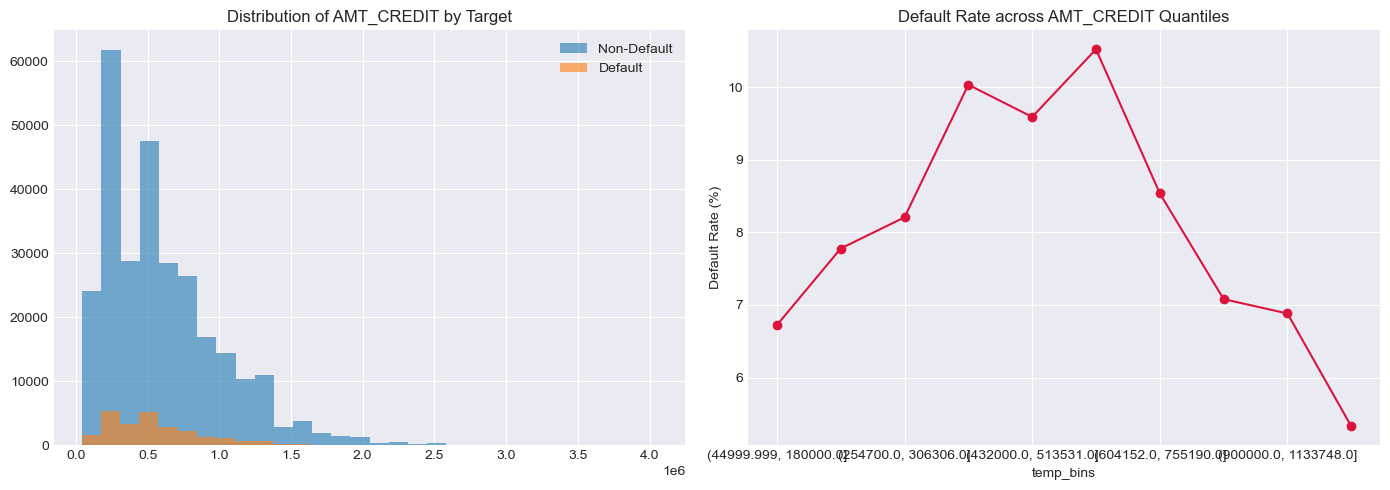

In [7]:
# 2. Credit Amount
plot_target_analysis('AMT_CREDIT', app_train)

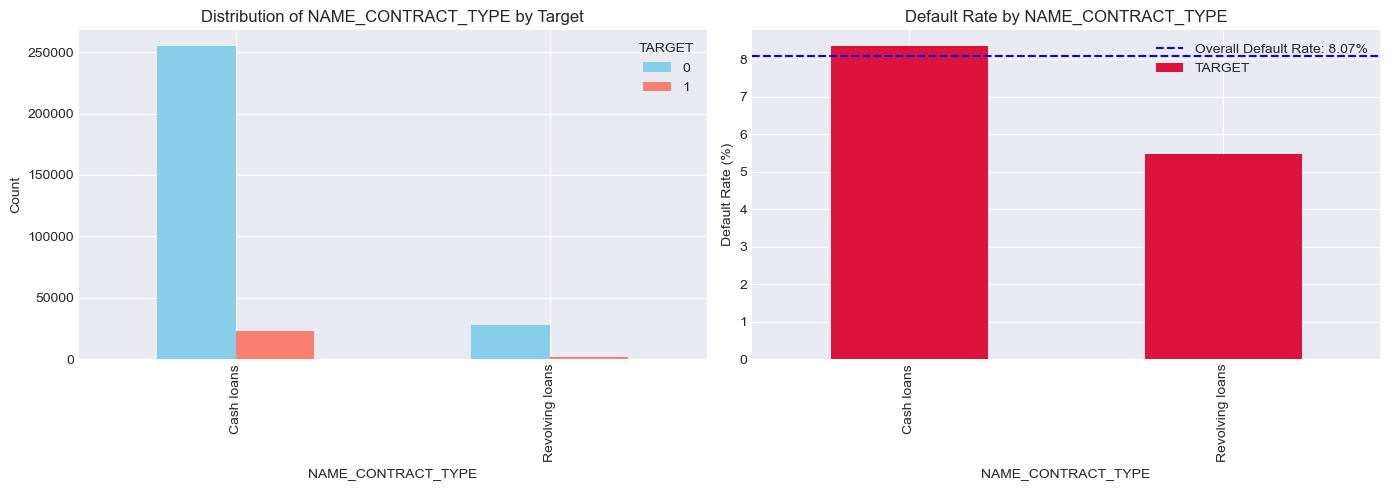

In [8]:
# 3. Contract Type
plot_target_analysis('NAME_CONTRACT_TYPE', app_train)

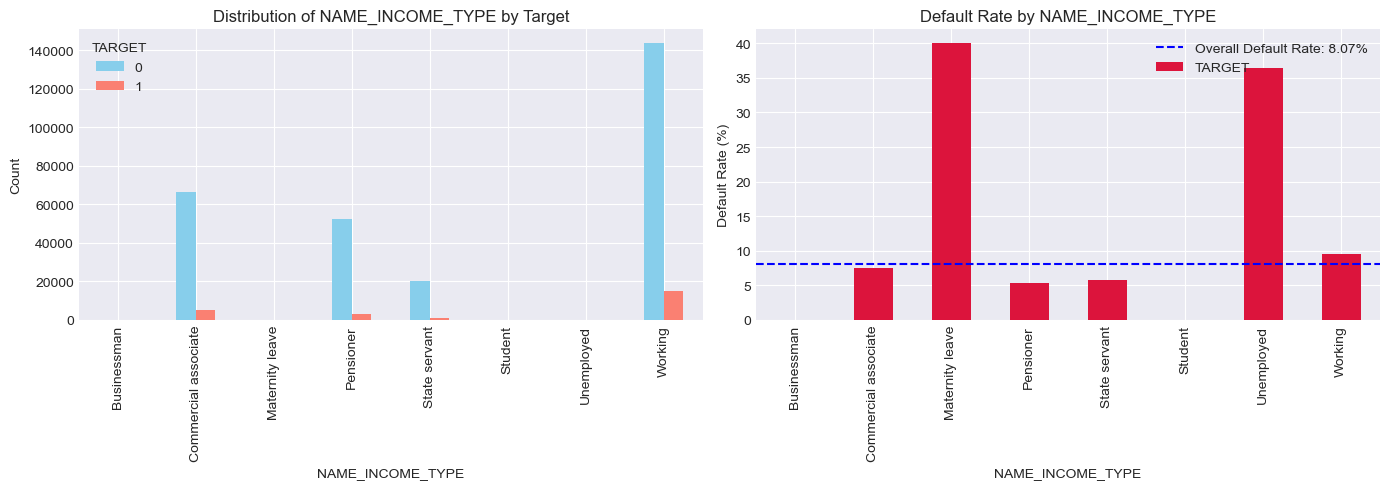

In [9]:
# 4. Income Type (Employment)
plot_target_analysis('NAME_INCOME_TYPE', app_train)

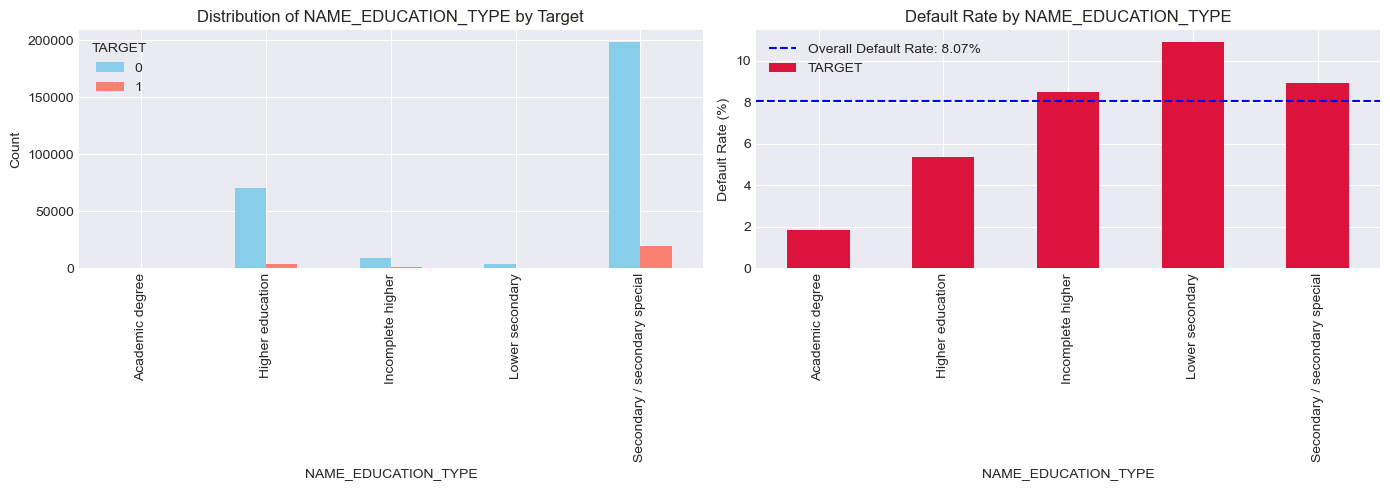

In [10]:
# 5. Education Level
plot_target_analysis('NAME_EDUCATION_TYPE', app_train)

Top 15 Positive Correlations with Default:
TARGET                         1.000000
DAYS_BIRTH                     0.078239
REGION_RATING_CLIENT_W_CITY    0.060893
REGION_RATING_CLIENT           0.058899
DAYS_LAST_PHONE_CHANGE         0.055218
DAYS_ID_PUBLISH                0.051457
REG_CITY_NOT_WORK_CITY         0.050994
FLAG_EMP_PHONE                 0.045982
REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_DOCUMENT_3                0.044346
DAYS_REGISTRATION              0.041975
OWN_CAR_AGE                    0.037612
LIVE_CITY_NOT_WORK_CITY        0.032518
DEF_30_CNT_SOCIAL_CIRCLE       0.032248
DEF_60_CNT_SOCIAL_CIRCLE       0.031276
Name: TARGET, dtype: float64

Top 15 Negative Correlations with Default:
LIVINGAREA_MEDI              -0.032739
LIVINGAREA_AVG               -0.032997
FLOORSMIN_MEDI               -0.033394
FLOORSMIN_AVG                -0.033614
ELEVATORS_MEDI               -0.033863
ELEVATORS_AVG                -0.034199
REGION_POPULATION_RELATIVE   -0.037227
AMT_GOODS_P

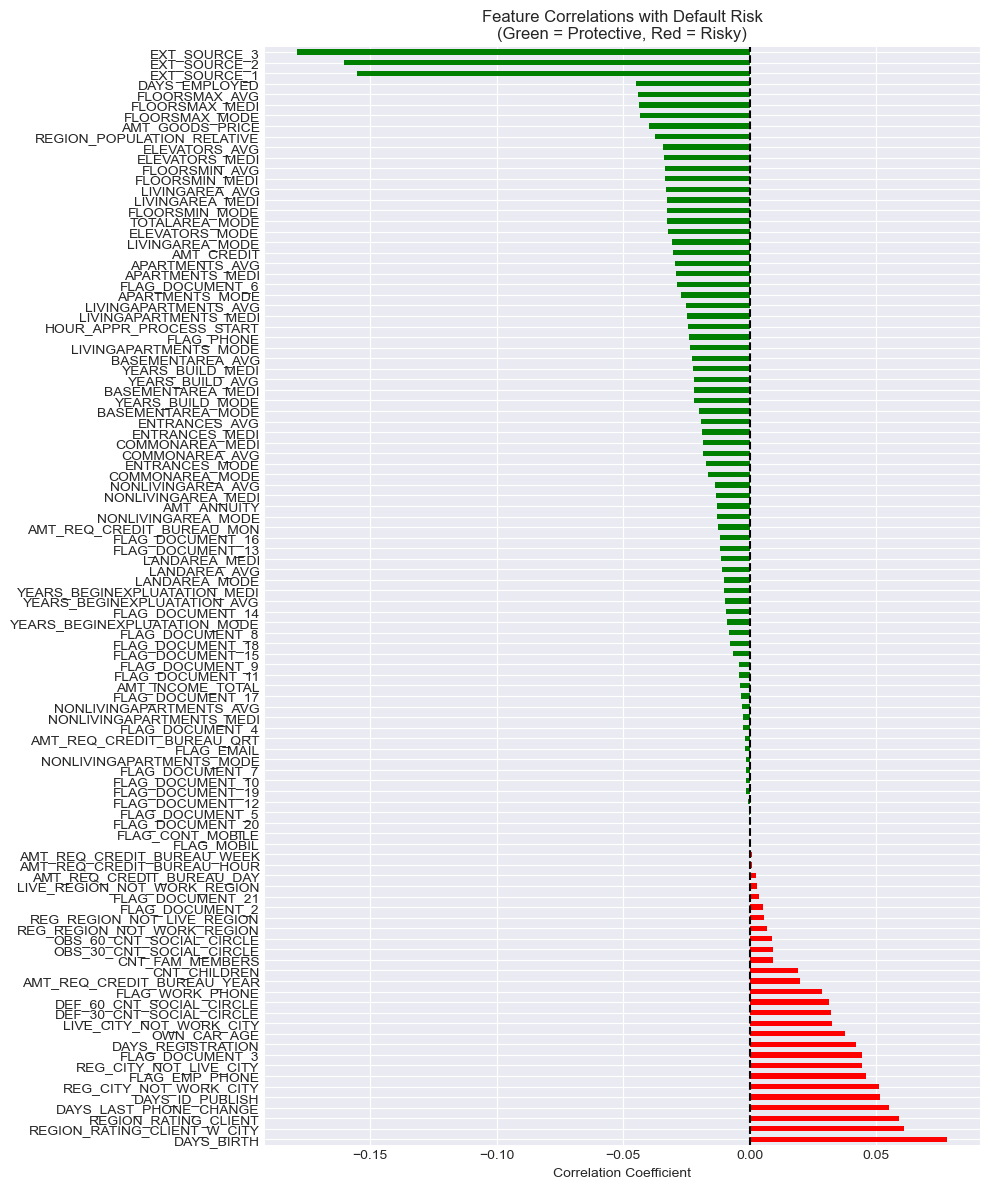

In [11]:
# =============================================================================
# STEP 4: Correlation with Target
# WHY: Identify strongest predictors for feature selection
# =============================================================================

# Calculate correlations
correlations = app_train[numeric_features + ['TARGET']].corr()['TARGET'].sort_values(ascending=False)

print("Top 15 Positive Correlations with Default:")
print(correlations.head(15))
print("\nTop 15 Negative Correlations with Default:")
print(correlations.tail(15))

# Visualize
plt.figure(figsize=(10, 12))
correlations.drop('TARGET').plot(kind='barh', color=['green' if x < 0 else 'red' for x in correlations.drop('TARGET')])
plt.title('Feature Correlations with Default Risk\n(Green = Protective, Red = Risky)')
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

EXT_SOURCE_1: 56.38% missing
EXT_SOURCE_2: 0.21% missing
EXT_SOURCE_3: 19.83% missing


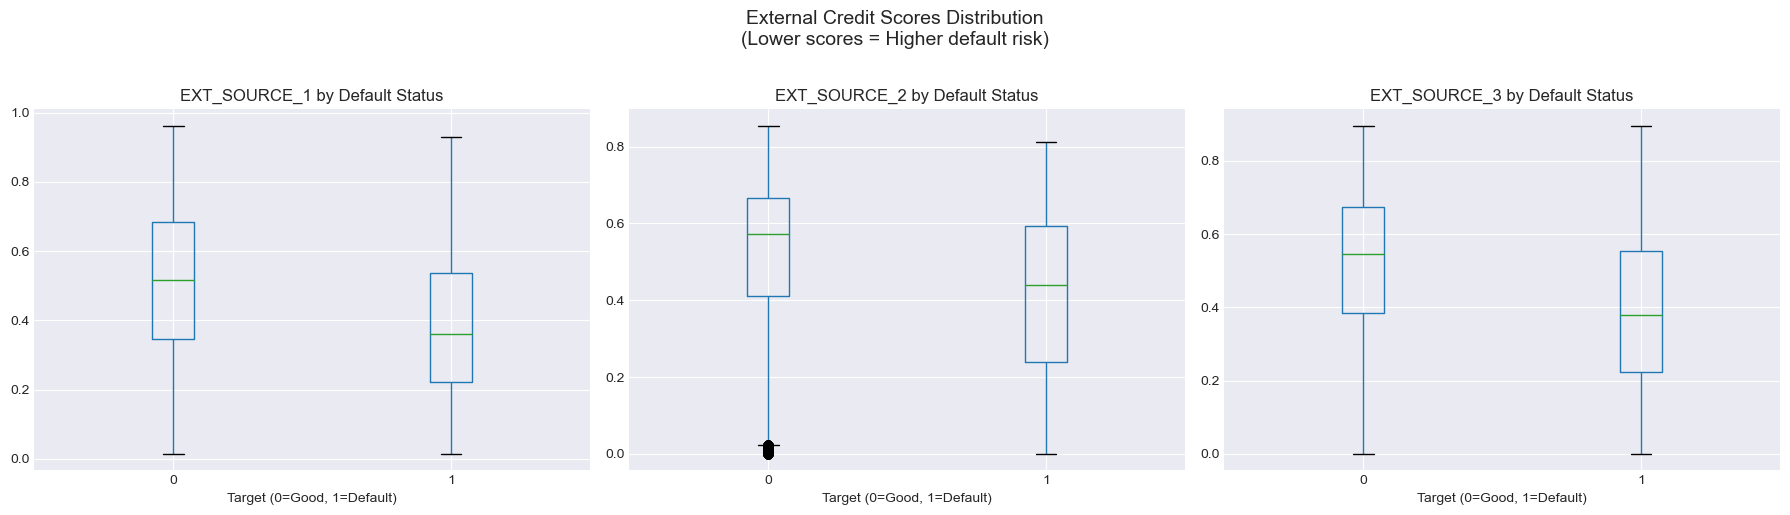

EXT_SOURCE_1: Mean difference is statistically significant (p < 0.001): True
EXT_SOURCE_2: Mean difference is statistically significant (p < 0.001): True
EXT_SOURCE_3: Mean difference is statistically significant (p < 0.001): True


In [12]:
# =============================================================================
# STEP 5: Deep Dive into EXT_SOURCE Features
# WHY: These are normalized credit bureau scores (0-1 scale)
# Banks use these heavily in practice
# =============================================================================

# Check availability
ext_sources = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
for col in ext_sources:
    missing_pct = app_train[col].isnull().sum() / len(app_train) * 100
    print(f"{col}: {missing_pct:.2f}% missing")

# Distribution by target
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(ext_sources):
    app_train.boxplot(column=col, by='TARGET', ax=axes[i])
    axes[i].set_title(f'{col} by Default Status')
    axes[i].set_xlabel('Target (0=Good, 1=Default)')
plt.suptitle('External Credit Scores Distribution\n(Lower scores = Higher default risk)', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Statistical test
from scipy.stats import ttest_ind
for col in ext_sources:
    good = app_train[app_train['TARGET'] == 0][col].dropna()
    bad = app_train[app_train['TARGET'] == 1][col].dropna()
    t_stat, p_value = ttest_ind(good, bad)
    print(f"{col}: Mean difference is statistically significant (p < 0.001): {p_value < 0.001}")

In [13]:
# =============================================================================
# STEP 6: Detect and Handle Outliers
# WHY: Outliers can represent:
# - Data errors (365,243 years employed = clearly wrong)
# - Fraud (income 10,000x median = suspicious)
# - Genuine edge cases (billionaires applying for small loans)
# =============================================================================

def detect_outliers(df, features, method='IQR'):
    """
    Banking approach to outlier detection:
    - Use domain knowledge first
    - Then statistical methods
    """
    outlier_summary = []
    
    for col in features:
        if col in df.columns and df[col].dtype in ['int64', 'float64']:
            # Statistics
            q1 = df[col].quantile(0.25)
            q3 = df[col].quantile(0.75)
            iqr = q3 - q1
            lower_bound = q1 - 3 * iqr  # Using 3*IQR (more conservative)
            upper_bound = q3 + 3 * iqr
            
            outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
            outlier_pct = (len(outliers) / len(df)) * 100
            
            outlier_summary.append({
                'feature': col,
                'outlier_count': len(outliers),
                'outlier_pct': outlier_pct,
                'min': df[col].min(),
                'max': df[col].max(),
                'median': df[col].median()
            })
    
    return pd.DataFrame(outlier_summary).sort_values('outlier_pct', ascending=False)

outlier_df = detect_outliers(app_train, numeric_features)
print("Features with Outliers (>5% of data):")
print(outlier_df[outlier_df['outlier_pct'] > 5].head(10))

Features with Outliers (>5% of data):
                         feature  outlier_count  outlier_pct      min  \
18          REGION_RATING_CLIENT          80527    26.186706      1.0   
19   REGION_RATING_CLIENT_W_CITY          78027    25.373726      1.0   
25        REG_CITY_NOT_WORK_CITY          70867    23.045354      0.0   
13               FLAG_WORK_PHONE          61308    19.936848      0.0   
7                  DAYS_EMPLOYED          59624    19.389225 -17912.0   
12                FLAG_EMP_PHONE          55386    18.011063      0.0   
26       LIVE_CITY_NOT_WORK_CITY          55215    17.955455      0.0   
102    AMT_REQ_CREDIT_BUREAU_QRT          50575    16.446566      0.0   
101    AMT_REQ_CREDIT_BUREAU_MON          43759    14.230060      0.0   
74      DEF_30_CNT_SOCIAL_CIRCLE          35166    11.435688      0.0   

          max  median  
18        3.0     2.0  
19        3.0     2.0  
25        1.0     0.0  
13        1.0     0.0  
7    365243.0 -1213.0  
12        1.0 

In [14]:
# =============================================================================
# STEP 7: Domain-Specific Outlier Handling
# =============================================================================

# DAYS_EMPLOYED: Has value 365243 for unemployed (encoding error)
print(f"Unique DAYS_EMPLOYED values with 365243: {(app_train['DAYS_EMPLOYED'] == 365243).sum()}")

# Create flag for unemployed and fix
app_train['FLAG_UNEMPLOYED'] = (app_train['DAYS_EMPLOYED'] == 365243).astype(int)
app_train['DAYS_EMPLOYED'].replace(365243, np.nan, inplace=True)

# Apply same to test set
app_test['FLAG_UNEMPLOYED'] = (app_test['DAYS_EMPLOYED'] == 365243).astype(int)
app_test['DAYS_EMPLOYED'].replace(365243, np.nan, inplace=True)

print("✓ Unemployment flag created and DAYS_EMPLOYED corrected")

# AMT_INCOME_TOTAL: Cap extreme values (banking practice: 99th percentile)
income_99 = app_train['AMT_INCOME_TOTAL'].quantile(0.99)
print(f"99th percentile income: {income_99:,.0f}")

app_train['AMT_INCOME_TOTAL'] = app_train['AMT_INCOME_TOTAL'].clip(upper=income_99)
app_test['AMT_INCOME_TOTAL'] = app_test['AMT_INCOME_TOTAL'].clip(upper=income_99)

print("✓ Income capped at 99th percentile")

Unique DAYS_EMPLOYED values with 365243: 55374
✓ Unemployment flag created and DAYS_EMPLOYED corrected
99th percentile income: 472,500
✓ Income capped at 99th percentile


In [15]:
# =============================================================================
# STEP 8: Strategic Missing Value Imputation
# Banking Logic:
# - Demographics: Use mode (most common category)
# - Financial: Use median (robust to outliers)
# - External scores: Use median BUT create missing flag
# - Employment: Missing = 0 days (unemployed)
# =============================================================================

def impute_missing_values(df):
    """
    Industry-standard imputation strategy
    """
    df = df.copy()
    
    # 1. Categorical: Mode (most frequent)
    categorical_cols = df.select_dtypes(include=['object']).columns
    for col in categorical_cols:
        if df[col].isnull().sum() > 0:
            df[col].fillna(df[col].mode()[0], inplace=True)
    
    # 2. External Sources: Median + Create missing flag
    ext_sources = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
    for col in ext_sources:
        if col in df.columns:
            df[f'{col}_MISSING'] = df[col].isnull().astype(int)
            df[col].fillna(df[col].median(), inplace=True)
    
    # 3. AMT features: Median
    amt_cols = [col for col in df.columns if col.startswith('AMT_')]
    for col in amt_cols:
        if df[col].isnull().sum() > 0:
            df[col].fillna(df[col].median(), inplace=True)
    
    # 4. DAYS features: 0 (meaning "not applicable")
    days_cols = [col for col in df.columns if col.startswith('DAYS_')]
    for col in days_cols:
        if df[col].isnull().sum() > 0:
            df[col].fillna(0, inplace=True)
    
    # 5. Remaining numerical: Median
    remaining_num = df.select_dtypes(include=['float64', 'int64']).columns
    for col in remaining_num:
        if df[col].isnull().sum() > 0:
            df[col].fillna(df[col].median(), inplace=True)
    
    return df

print("Before imputation:")
print(f"Total missing values: {app_train.isnull().sum().sum()}")

app_train = impute_missing_values(app_train)
app_test = impute_missing_values(app_test)

print("\nAfter imputation:")
print(f"Total missing values in train: {app_train.isnull().sum().sum()}")
print(f"Total missing values in test: {app_test.isnull().sum().sum()}")

Before imputation:
Total missing values: 9207839

After imputation:
Total missing values in train: 0
Total missing values in test: 0


In [16]:
# =============================================================================
# STEP 9: Create Banking-Specific Features
# WHY: Raw features don't capture risk relationships
# Banks use financial ratios extensively
# =============================================================================

def engineer_features(df):
    """
    Create features based on banking domain knowledge
    """
    df = df.copy()
    
    # -------------------------------------------------------------------------
    # 1. INCOME RATIOS (Debt Serviceability)
    # -------------------------------------------------------------------------
    # Credit to Income: How much are they borrowing relative to income?
    # Rule: Should be < 3x income
    df['CREDIT_INCOME_RATIO'] = df['AMT_CREDIT'] / (df['AMT_INCOME_TOTAL'] + 1)
    
    # Annuity (EMI) to Income: Can they afford monthly payments?
    # Rule: Should be < 40% of income
    df['ANNUITY_INCOME_RATIO'] = df['AMT_ANNUITY'] / (df['AMT_INCOME_TOTAL'] + 1)
    
    # Loan-to-Value (LTV): How much of the goods price are they financing?
    # Lower LTV = more skin in the game = lower risk
    df['LTV_RATIO'] = df['AMT_CREDIT'] / (df['AMT_GOODS_PRICE'] + 1)
    
    # -------------------------------------------------------------------------
    # 2. EMPLOYMENT STABILITY
    # -------------------------------------------------------------------------
    # Employment to Age ratio: How much of their life have they worked?
    # Higher = more stable
    df['EMPLOYMENT_TO_AGE_RATIO'] = df['DAYS_EMPLOYED'] / (df['DAYS_BIRTH'] + 1)
    
    # Income per family member
    df['INCOME_PER_PERSON'] = df['AMT_INCOME_TOTAL'] / (df['CNT_FAM_MEMBERS'] + 1)
    
    # -------------------------------------------------------------------------
    # 3. EXTERNAL SOURCE COMBINATIONS (Most Powerful)
    # -------------------------------------------------------------------------
    # Average of all external sources
    ext_cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
    df['EXT_SOURCE_MEAN'] = df[ext_cols].mean(axis=1)
    df['EXT_SOURCE_STD'] = df[ext_cols].std(axis=1)
    df['EXT_SOURCE_MIN'] = df[ext_cols].min(axis=1)
    df['EXT_SOURCE_MAX'] = df[ext_cols].max(axis=1)
    
    # Weighted average (EXT_SOURCE_2 and 3 are stronger predictors)
    df['EXT_SOURCE_WEIGHTED'] = (df['EXT_SOURCE_1'] * 0.2 + 
                                   df['EXT_SOURCE_2'] * 0.4 + 
                                   df['EXT_SOURCE_3'] * 0.4)
    
    # -------------------------------------------------------------------------
    # 4. AGE GROUPS (Non-linear relationship with risk)
    # -------------------------------------------------------------------------
    df['AGE_YEARS'] = -df['DAYS_BIRTH'] / 365
    df['AGE_GROUP'] = pd.cut(df['AGE_YEARS'], 
                              bins=[0, 25, 35, 45, 55, 100], 
                              labels=['Very Young', 'Young', 'Middle', 'Senior', 'Elderly'])
    
    # -------------------------------------------------------------------------
    # 5. DOCUMENT FLAGS (Application Completeness)
    # -------------------------------------------------------------------------
    # Count how many documents were provided
    doc_cols = [col for col in df.columns if col.startswith('FLAG_DOCUMENT')]
    df['DOCUMENT_COUNT'] = df[doc_cols].sum(axis=1)
    
    # -------------------------------------------------------------------------
    # 6. ENQUIRY FLAGS (Credit Hungry Indicator)
    # -------------------------------------------------------------------------
    enquiry_cols = [col for col in df.columns if col.startswith('AMT_REQ_CREDIT_BUREAU')]
    df['TOTAL_ENQUIRIES'] = df[enquiry_cols].sum(axis=1)
    
    return df

# Apply feature engineering
print("Engineering features...")
app_train = engineer_features(app_train)
app_test = engineer_features(app_test)

print(f"New feature count: {app_train.shape[1]}")

# Show new features
new_features = ['CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'LTV_RATIO',
                'EXT_SOURCE_MEAN', 'EMPLOYMENT_TO_AGE_RATIO', 'INCOME_PER_PERSON']
print("\nNew Features Summary:")
print(app_train[new_features].describe())

Engineering features...
New feature count: 140

New Features Summary:
       CREDIT_INCOME_RATIO  ANNUITY_INCOME_RATIO      LTV_RATIO  \
count        307511.000000         307511.000000  307511.000000   
mean              3.963725              0.181220       1.122538   
std               2.686359              0.094396       0.125542   
min               0.095238              0.008700       0.150000   
25%               2.027173              0.115269       0.999999   
50%               3.275850              0.162932       1.118798   
75%               5.165495              0.229155       1.197998   
max              84.733539              1.875892       5.999867   

       EXT_SOURCE_MEAN  EMPLOYMENT_TO_AGE_RATIO  INCOME_PER_PERSON  
count    307511.000000            307511.000000      307511.000000  
mean          0.511503                 0.128624       56600.730403  
std           0.108104                 0.135125       32502.270203  
min           0.023705                -0.000000   

In [17]:
# =============================================================================
# STEP 10: Label Encoding for Categorical Features
# WHY: ML models need numerical inputs
# Using Label Encoding (not One-Hot) to avoid dimensionality explosion
# =============================================================================

def encode_categorical(df, encoder_dict=None):
    """
    Label encode categorical variables
    Return encoded df and encoder dict for test set
    """
    df = df.copy()
    categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
    
    # Remove AGE_GROUP if it exists (will handle separately)
    if 'AGE_GROUP' in categorical_cols:
        categorical_cols.remove('AGE_GROUP')
    
    if encoder_dict is None:
        encoder_dict = {}
        for col in categorical_cols:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col].astype(str))
            encoder_dict[col] = le
    else:
        for col in categorical_cols:
            if col in encoder_dict:
                # Transform using existing encoder
                df[col] = encoder_dict[col].transform(df[col].astype(str))
    
    # Handle AGE_GROUP separately (ordinal encoding)
    if 'AGE_GROUP' in df.columns:
        age_map = {'Very Young': 0, 'Young': 1, 'Middle': 2, 'Senior': 3, 'Elderly': 4}
        df['AGE_GROUP'] = df['AGE_GROUP'].map(age_map)
    
    return df, encoder_dict

# Encode training data
app_train_encoded, encoders = encode_categorical(app_train)

# Encode test data using same encoders
app_test_encoded, _ = encode_categorical(app_test, encoder_dict=encoders)

print(f"✓ Categorical encoding complete")
print(f"Encoded columns: {len(encoders)}")

✓ Categorical encoding complete
Encoded columns: 16


In [18]:
# =============================================================================
# STEP 11: Prepare Data for Modeling
# =============================================================================

# Separate features and target
X = app_train_encoded.drop(['TARGET', 'SK_ID_CURR'], axis=1, errors='ignore')
y = app_train_encoded['TARGET']

# Train-validation split (Stratified to preserve class imbalance)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"\nClass distribution in train:")
print(y_train.value_counts(normalize=True))
print(f"\nClass distribution in validation:")
print(y_val.value_counts(normalize=True))

# Feature Scaling (important for Logistic Regression, not for tree models)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Convert back to DataFrame for easier handling
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X_val.columns, index=X_val.index)

print("\n✓ Data scaling complete")

Training set: (246008, 138)
Validation set: (61503, 138)

Class distribution in train:
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64

Class distribution in validation:
TARGET
0    0.919272
1    0.080728
Name: proportion, dtype: float64

✓ Data scaling complete


BASELINE MODEL: LOGISTIC REGRESSION
Training AUC: 0.7494
Validation AUC: 0.7493


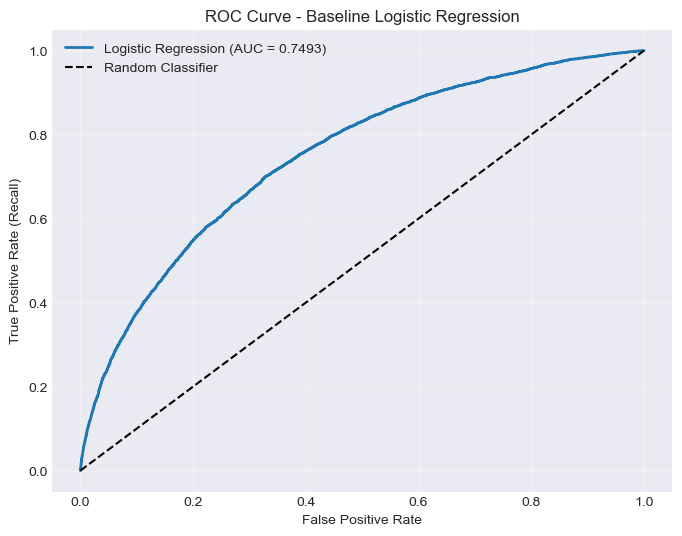


Top 20 Most Important Features:
                      feature  coefficient
120           FLAG_UNEMPLOYED    -0.460059
8             AMT_GOODS_PRICE    -0.351331
71          BASEMENTAREA_MEDI     0.334966
43           BASEMENTAREA_AVG    -0.330145
21             FLAG_EMP_PHONE    -0.324628
6                  AMT_CREDIT     0.287384
53             LIVINGAREA_AVG     0.282064
80      LIVINGAPARTMENTS_MEDI     0.276199
81            LIVINGAREA_MEDI    -0.232895
73           YEARS_BUILD_MEDI    -0.231175
41               EXT_SOURCE_3    -0.221354
45            YEARS_BUILD_AVG     0.217881
27            CNT_FAM_MEMBERS    -0.215435
89   OBS_30_CNT_SOCIAL_CIRCLE     0.208782
4                CNT_CHILDREN     0.200224
74            COMMONAREA_MEDI    -0.196923
91   OBS_60_CNT_SOCIAL_CIRCLE    -0.196113
133       EXT_SOURCE_WEIGHTED    -0.193720
130            EXT_SOURCE_STD     0.188262
129           EXT_SOURCE_MEAN    -0.182200


In [19]:
# =============================================================================
# STEP 12: Baseline Logistic Regression 
# WHY: Establishes performance floor
# Banks love interpretability - LR provides odds ratios
# =============================================================================

print("=" * 80)
print("BASELINE MODEL: LOGISTIC REGRESSION")
print("=" * 80)

# Train baseline model
lr_baseline = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_baseline.fit(X_train_scaled, y_train)

# Predictions
y_train_pred_lr = lr_baseline.predict_proba(X_train_scaled)[:, 1]
y_val_pred_lr = lr_baseline.predict_proba(X_val_scaled)[:, 1]

# Evaluate
train_auc_lr = roc_auc_score(y_train, y_train_pred_lr)
val_auc_lr = roc_auc_score(y_val, y_val_pred_lr)

print(f"Training AUC: {train_auc_lr:.4f}")
print(f"Validation AUC: {val_auc_lr:.4f}")

# Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_val, y_val_pred_lr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {val_auc_lr:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve - Baseline Logistic Regression')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Feature Importance (Top 20)
feature_importance_lr = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': lr_baseline.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

print("\nTop 20 Most Important Features:")
print(feature_importance_lr.head(20))

In [20]:
# =============================================================================
# STEP 13: Address Class Imbalance
# WHY: Model is biased toward majority class (non-defaulters)
# Banking Solution: SMOTE (Synthetic Minority Oversampling)
# =============================================================================

from imblearn.over_sampling import SMOTE

print("=" * 80)
print("HANDLING CLASS IMBALANCE WITH SMOTE")
print("=" * 80)

print("Before SMOTE:")
print(y_train.value_counts())

# Apply SMOTE (create synthetic defaulters to balance classes)
smote = SMOTE(random_state=42, sampling_strategy=0.5)  # 50% defaulters after resampling
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("\nAfter SMOTE:")
print(pd.Series(y_train_resampled).value_counts())

# Retrain Logistic Regression on balanced data
lr_smote = LogisticRegression(max_iter=1000, random_state=42)
lr_smote.fit(X_train_resampled, y_train_resampled)

y_val_pred_lr_smote = lr_smote.predict_proba(X_val_scaled)[:, 1]
val_auc_lr_smote = roc_auc_score(y_val, y_val_pred_lr_smote)

print(f"\nValidation AUC after SMOTE: {val_auc_lr_smote:.4f}")
print(f"Improvement: {val_auc_lr_smote - val_auc_lr:.4f}")


HANDLING CLASS IMBALANCE WITH SMOTE
Before SMOTE:
TARGET
0    226148
1     19860
Name: count, dtype: int64

After SMOTE:
TARGET
0    226148
1    113074
Name: count, dtype: int64

Validation AUC after SMOTE: 0.7445
Improvement: -0.0048


ADVANCED MODEL: RANDOM FOREST
Random Forest Validation AUC: 0.6114

Top 20 Important Features (Random Forest):
                        feature  importance
129             EXT_SOURCE_MEAN    0.083231
131              EXT_SOURCE_MIN    0.083223
133         EXT_SOURCE_WEIGHTED    0.082621
11          NAME_EDUCATION_TYPE    0.052755
132              EXT_SOURCE_MAX    0.048655
121        EXT_SOURCE_1_MISSING    0.043474
1                   CODE_GENDER    0.043382
119  AMT_REQ_CREDIT_BUREAU_YEAR    0.039901
126                   LTV_RATIO    0.037930
2                  FLAG_OWN_CAR    0.034492
24                   FLAG_PHONE    0.031350
40                 EXT_SOURCE_2    0.028089
41                 EXT_SOURCE_3    0.026934
83           NONLIVINGAREA_MEDI    0.025309
69           NONLIVINGAREA_MODE    0.024877
135                   AGE_GROUP    0.022108
137             TOTAL_ENQUIRIES    0.020139
55            NONLIVINGAREA_AVG    0.019946
30   WEEKDAY_APPR_PROCESS_START    0.017332
87       

<Figure size 1000x800 with 0 Axes>

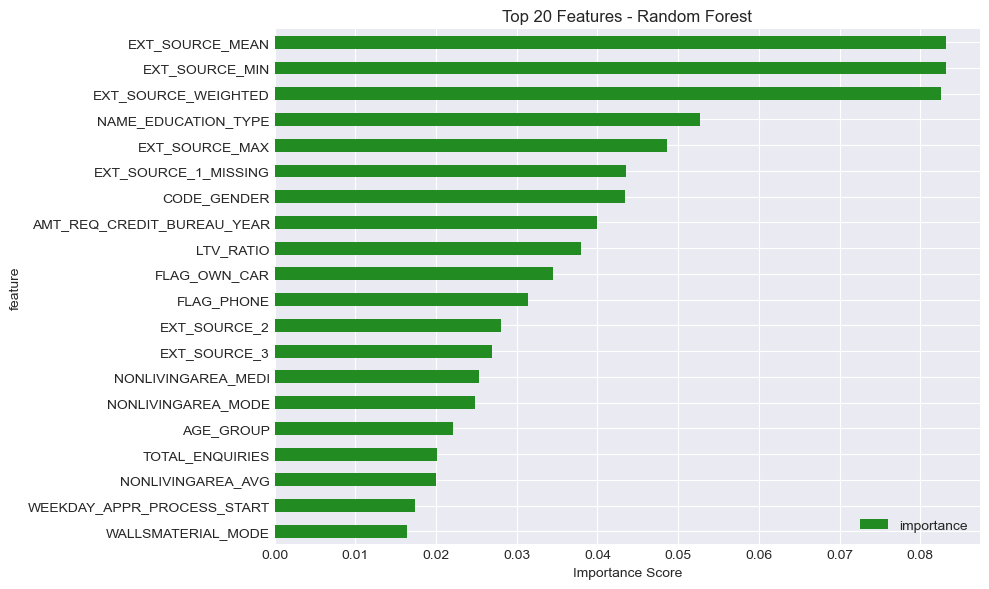

In [21]:
# =============================================================================
# STEP 14: Random Forest Classifier
# WHY: Handles non-linear relationships, feature interactions
# No need for scaling, robust to outliers
# =============================================================================

print("=" * 80)
print("ADVANCED MODEL: RANDOM FOREST")
print("=" * 80)

# Train Random Forest on SMOTE data
rf_model = RandomForestClassifier(
    n_estimators=100,        # 100 trees (balance between performance and speed)
    max_depth=10,            # Prevent overfitting
    min_samples_split=50,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1,               # Use all CPU cores
    class_weight='balanced'  # Handle remaining imbalance
)

# Note: RF doesn't need scaled data
rf_model.fit(X_train_resampled, y_train_resampled)

# Predictions
y_val_pred_rf = rf_model.predict_proba(X_val)[:, 1]
val_auc_rf = roc_auc_score(y_val, y_val_pred_rf)

print(f"Random Forest Validation AUC: {val_auc_rf:.4f}")

# Feature Importance from RF
feature_importance_rf = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 20 Important Features (Random Forest):")
print(feature_importance_rf.head(20))

# Visualize
plt.figure(figsize=(10, 8))
feature_importance_rf.head(20).plot(x='feature', y='importance', kind='barh', color='forestgreen')
plt.xlabel('Importance Score')
plt.title('Top 20 Features - Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [22]:
# =============================================================================
# STEP 15: XGBoost - Industry Standard for Credit Risk
# WHY: Best performance, handles imbalance well, provides feature importance
# Used by most banks and fintech companies
# =============================================================================

# Check current data type
print("AGE_GROUP dtype before:", X_train['AGE_GROUP'].dtype)

# Convert category to numeric (if it exists)
if 'AGE_GROUP' in X_train.columns:
    X_train['AGE_GROUP'] = X_train['AGE_GROUP'].astype(int)
    X_val['AGE_GROUP'] = X_val['AGE_GROUP'].astype(int)
    print("✓ AGE_GROUP converted to int")

# Verify all columns are numeric
print("\nData types check:")
print(X_train.dtypes.value_counts())

# Now train XGBoost
print("=" * 80)
print("PRODUCTION MODEL: XGBOOST")
print("=" * 80)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='auc',
    enable_categorical=False  # Changed to False since we converted to int
)

# Train with early stopping
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

# Predictions
y_val_pred_xgb = xgb_model.predict_proba(X_val)[:, 1]
val_auc_xgb = roc_auc_score(y_val, y_val_pred_xgb)

print(f"\nXGBoost Validation AUC: {val_auc_xgb:.4f}")

# Feature Importance
feature_importance_xgb = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 20 Important Features (XGBoost):")
print(feature_importance_xgb.head(20))


AGE_GROUP dtype before: category
✓ AGE_GROUP converted to int

Data types check:
float64    78
int64      39
int32      21
Name: count, dtype: int64
PRODUCTION MODEL: XGBOOST
[0]	validation_0-auc:0.72462
[50]	validation_0-auc:0.75108
[100]	validation_0-auc:0.75863
[150]	validation_0-auc:0.76152
[199]	validation_0-auc:0.76226

XGBoost Validation AUC: 0.7623

Top 20 Important Features (XGBoost):
                      feature  importance
129           EXT_SOURCE_MEAN    0.089316
133       EXT_SOURCE_WEIGHTED    0.068119
11        NAME_EDUCATION_TYPE    0.016892
131            EXT_SOURCE_MIN    0.015486
1                 CODE_GENDER    0.015464
126                 LTV_RATIO    0.013210
121      EXT_SOURCE_1_MISSING    0.013062
95            FLAG_DOCUMENT_3    0.012966
132            EXT_SOURCE_MAX    0.012653
123      EXT_SOURCE_3_MISSING    0.012042
2                FLAG_OWN_CAR    0.011897
21             FLAG_EMP_PHONE    0.011189
8             AMT_GOODS_PRICE    0.010929
10           NA

                 Model   AUC-ROC
3              XGBoost  0.762261
0  Logistic Regression  0.749256
1           LR + SMOTE  0.744465
2        Random Forest  0.611404


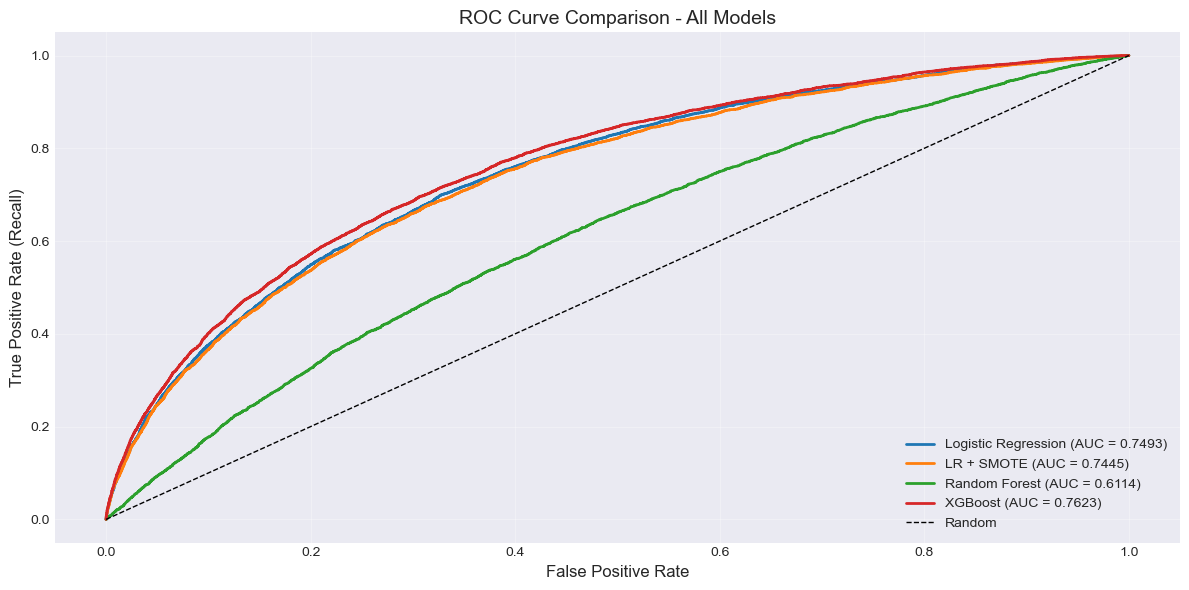

In [23]:
# =============================================================================
# STEP 16: Compare All Models
# =============================================================================

# Collect predictions
models = {
    'Logistic Regression': y_val_pred_lr,
    'LR + SMOTE': y_val_pred_lr_smote,
    'Random Forest': y_val_pred_rf,
    'XGBoost': y_val_pred_xgb
}

# Calculate AUC for all
results = []
for name, preds in models.items():
    auc = roc_auc_score(y_val, preds)
    results.append({'Model': name, 'AUC-ROC': auc})

results_df = pd.DataFrame(results).sort_values('AUC-ROC', ascending=False)
print(results_df)

# Plot comparison
plt.figure(figsize=(12, 6))
for name, preds in models.items():
    fpr, tpr, _ = roc_curve(y_val, preds)
    auc = roc_auc_score(y_val, preds)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random', linewidth=1)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curve Comparison - All Models', fontsize=14)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

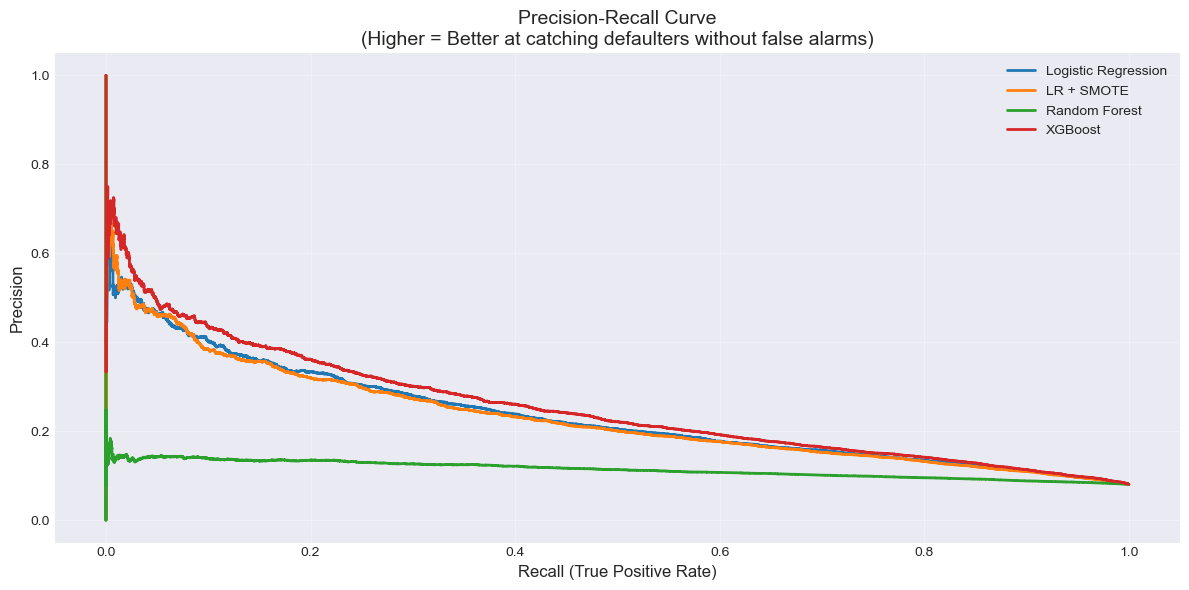

In [24]:
# =============================================================================
# STEP 17: Precision-Recall Trade-off
# WHY: In imbalanced datasets, PR curve is more informative than ROC
# Banking focus: Maximize recall (catch defaulters) while maintaining precision
# =============================================================================

plt.figure(figsize=(12, 6))

for name, preds in models.items():
    precision, recall, _ = precision_recall_curve(y_val, preds)
    plt.plot(recall, precision, label=name, linewidth=2)

plt.xlabel('Recall (True Positive Rate)', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve\n(Higher = Better at catching defaulters without false alarms)', 
          fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Optimal Threshold: 0.500
F2-Score at optimal threshold: 0.4254

Confusion Matrix:
[[40735 15803]
 [ 1649  3316]]


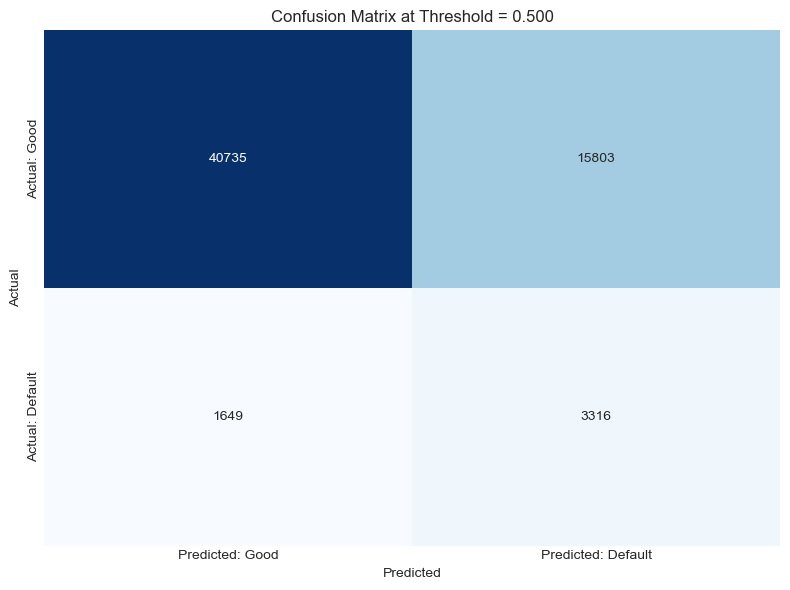


Performance Metrics:
True Negatives (Correct rejections): 40735
False Positives (Good customers rejected): 15803
False Negatives (Defaulters approved - COSTLY): 1649
True Positives (Defaulters caught): 3316

Recall (Catch rate for defaulters): 66.79%
Precision: 17.34%
False Negative Rate (Miss rate): 33.21%


In [25]:
# =============================================================================
# STEP 18: Find Optimal Decision Threshold
# Banking Logic: Maximize F2-score (prioritizes recall over precision)
# =============================================================================

from sklearn.metrics import f1_score, fbeta_score

def find_optimal_threshold(y_true, y_pred_proba, beta=2):
    """
    Find threshold that maximizes F-beta score
    beta=2 means recall is 2x more important than precision
    """
    thresholds = np.arange(0.1, 0.9, 0.01)
    scores = []
    
    for thresh in thresholds:
        y_pred_class = (y_pred_proba >= thresh).astype(int)
        score = fbeta_score(y_true, y_pred_class, beta=beta)
        scores.append({'threshold': thresh, 'f2_score': score})
    
    scores_df = pd.DataFrame(scores)
    optimal = scores_df.loc[scores_df['f2_score'].idxmax()]
    return optimal['threshold'], optimal['f2_score']

# Find optimal threshold for XGBoost
optimal_thresh, optimal_f2 = find_optimal_threshold(y_val, y_val_pred_xgb)
print(f"Optimal Threshold: {optimal_thresh:.3f}")
print(f"F2-Score at optimal threshold: {optimal_f2:.4f}")

# Generate predictions at optimal threshold
y_val_pred_class = (y_val_pred_xgb >= optimal_thresh).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_val, y_val_pred_class)
print("\nConfusion Matrix:")
print(cm)

# Visualize
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted: Good', 'Predicted: Default'],
            yticklabels=['Actual: Good', 'Actual: Default'])
plt.title(f'Confusion Matrix at Threshold = {optimal_thresh:.3f}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# Calculate metrics
tn, fp, fn, tp = cm.ravel()
print(f"\nPerformance Metrics:")
print(f"True Negatives (Correct rejections): {tn}")
print(f"False Positives (Good customers rejected): {fp}")
print(f"False Negatives (Defaulters approved - COSTLY): {fn}")
print(f"True Positives (Defaulters caught): {tp}")
print(f"\nRecall (Catch rate for defaulters): {tp/(tp+fn):.2%}")
print(f"Precision: {tp/(tp+fp):.2%}")
print(f"False Negative Rate (Miss rate): {fn/(fn+tp):.2%}")


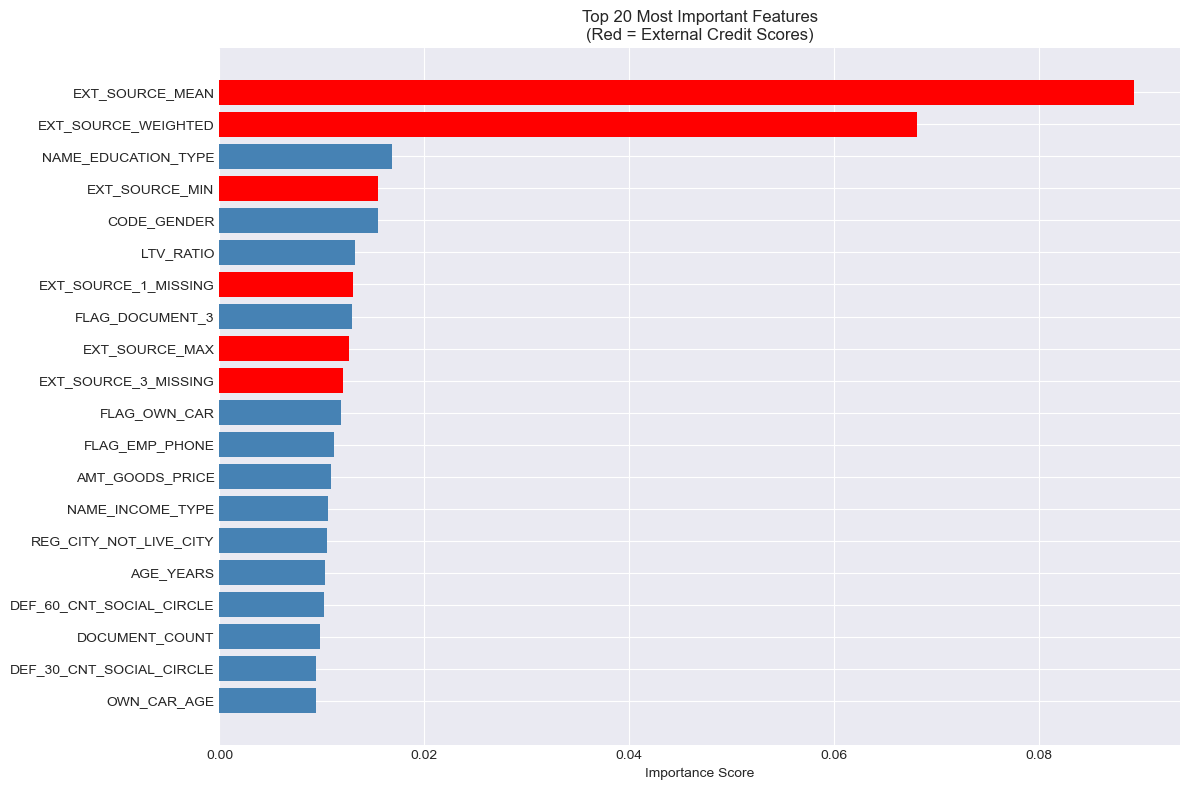

Top 20 Important Features:
                      feature  importance
129           EXT_SOURCE_MEAN    0.089316
133       EXT_SOURCE_WEIGHTED    0.068119
11        NAME_EDUCATION_TYPE    0.016892
131            EXT_SOURCE_MIN    0.015486
1                 CODE_GENDER    0.015464
126                 LTV_RATIO    0.013210
121      EXT_SOURCE_1_MISSING    0.013062
95            FLAG_DOCUMENT_3    0.012966
132            EXT_SOURCE_MAX    0.012653
123      EXT_SOURCE_3_MISSING    0.012042
2                FLAG_OWN_CAR    0.011897
21             FLAG_EMP_PHONE    0.011189
8             AMT_GOODS_PRICE    0.010929
10           NAME_INCOME_TYPE    0.010582
35     REG_CITY_NOT_LIVE_CITY    0.010506
134                 AGE_YEARS    0.010289
92   DEF_60_CNT_SOCIAL_CIRCLE    0.010227
136            DOCUMENT_COUNT    0.009861
90   DEF_30_CNT_SOCIAL_CIRCLE    0.009458
19                OWN_CAR_AGE    0.009414

Calculating permutation importance (this may take a minute)...

Top 20 Features (Permutati

IndexError: index 0 is out of bounds for axis 0 with size 0

In [26]:
# =============================================================================
# FEATURE IMPORTANCE ANALYSIS
# =============================================================================

# Method 1: XGBoost Built-in Feature Importance
feature_importance_xgb = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

# Visualize top 20
plt.figure(figsize=(12, 8))
top_20 = feature_importance_xgb.head(20)
colors = ['red' if 'EXT_SOURCE' in feat else 'steelblue' for feat in top_20['feature']]
plt.barh(range(len(top_20)), top_20['importance'], color=colors)
plt.yticks(range(len(top_20)), top_20['feature'])
plt.xlabel('Importance Score')
plt.title('Top 20 Most Important Features\n(Red = External Credit Scores)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Top 20 Important Features:")
print(feature_importance_xgb.head(20))

# Method 2: Permutation Importance (more reliable than feature_importances_)
from sklearn.inspection import permutation_importance

print("\nCalculating permutation importance (this may take a minute)...")
perm_importance = permutation_importance(
    xgb_model, X_val.head(5000), y_val.head(5000), 
    n_repeats=10, random_state=42, n_jobs=-1
)

perm_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': perm_importance.importances_mean
}).sort_values('importance', ascending=False)

print("\nTop 20 Features (Permutation Importance):")
print(perm_importance_df.head(20))

# Method 3: Individual Prediction Explanation
def explain_customer_decision(customer_idx):
    """
    Explain why a customer was approved/rejected
    """
    customer = X_val.iloc[customer_idx:customer_idx+1]
    prob = xgb_model.predict_proba(customer)[0, 1]
    decision = "REJECT - High Risk" if prob > 0.5 else "APPROVE - Low Risk"
    
    print("="*80)
    print(f"CUSTOMER PREDICTION EXPLANATION")
    print("="*80)
    print(f"Default Probability: {prob:.2%}")
    print(f"Decision: {decision}")
    print(f"\nTop 10 Risk Indicators for this customer:")
    
    top_features = feature_importance_xgb.head(10)['feature']
    for i, feat in enumerate(top_features, 1):
        val = customer[feat].values[0]
        avg_val = X_train[feat].mean()
        diff = val - avg_val
        direction = "↑ Higher" if diff > 0 else "↓ Lower"
        print(f"{i:2d}. {feat:30s}: {val:10.4f} ({direction} than average by {abs(diff):.2f})")
    
    return prob

# Test explanation on a high-risk customer
high_risk_idx = y_val[y_val == 1].index[0]  # Find a defaulter
explain_customer_decision(high_risk_idx)

In [27]:
# =============================================================================
# SIMPLER VERSION: Just using positions 0-9
# =============================================================================

def explain_customer(position):
    """Simple explanation using position in validation set"""
    customer = X_val.iloc[position:position+1]
    prob = xgb_model.predict_proba(customer)[0, 1]
    actual = y_val.iloc[position]
    
    print("="*80)
    print(f"CUSTOMER #{position} RISK ASSESSMENT")
    print("="*80)
    print(f"Default Probability: {prob:.2%}")
    print(f"Recommendation: {'REJECT ❌' if prob > 0.5 else 'APPROVE ✅'}")
    print(f"Actual Outcome: {'Defaulted' if actual == 1 else 'Repaid'}")
    print(f"Model was: {'CORRECT ✓' if (prob > 0.5) == actual else 'WRONG ✗'}")
    
    print(f"\nTop 8 Risk Drivers:")
    top_features = feature_importance_xgb.head(8)['feature']
    for i, feat in enumerate(top_features, 1):
        val = customer[feat].values[0]
        avg_val = X_train[feat].mean()
        
        if 'EXT_SOURCE' in feat:
            status = "LOW (Risky)" if val < 0.5 else "HIGH (Good)"
        else:
            status = f"{val:.3f}"
        
        print(f"  {i}. {feat:30s}: {status}")
    
    return prob

# Find some defaulters manually
print("Finding defaulters in validation set...")
for i in range(100):
    if y_val.iloc[i] == 1:
        print(f"\n🔴 DEFAULTER FOUND AT POSITION {i}")
        explain_customer(i)
        break

# Find a good customer
print("\n" + "="*80)
for i in range(100):
    if y_val.iloc[i] == 0:
        print(f"\n🟢 GOOD CUSTOMER FOUND AT POSITION {i}")
        explain_customer(i)
        break

Finding defaulters in validation set...

🔴 DEFAULTER FOUND AT POSITION 9
CUSTOMER #9 RISK ASSESSMENT
Default Probability: 54.70%
Recommendation: REJECT ❌
Actual Outcome: Defaulted
Model was: CORRECT ✓

Top 8 Risk Drivers:
  1. EXT_SOURCE_MEAN               : LOW (Risky)
  2. EXT_SOURCE_WEIGHTED           : LOW (Risky)
  3. NAME_EDUCATION_TYPE           : 4.000
  4. EXT_SOURCE_MIN                : LOW (Risky)
  5. CODE_GENDER                   : 0.000
  6. LTV_RATIO                     : 1.000
  7. EXT_SOURCE_1_MISSING          : LOW (Risky)
  8. FLAG_DOCUMENT_3               : 0.000


🟢 GOOD CUSTOMER FOUND AT POSITION 0
CUSTOMER #0 RISK ASSESSMENT
Default Probability: 38.37%
Recommendation: APPROVE ✅
Actual Outcome: Repaid
Model was: CORRECT ✓

Top 8 Risk Drivers:
  1. EXT_SOURCE_MEAN               : HIGH (Good)
  2. EXT_SOURCE_WEIGHTED           : HIGH (Good)
  3. NAME_EDUCATION_TYPE           : 1.000
  4. EXT_SOURCE_MIN                : LOW (Risky)
  5. CODE_GENDER                   

In [32]:
# =============================================================================
# Save Model and Preprocessing Pipeline
# =============================================================================

import joblib

# Save model
joblib.dump(xgb_model, 'credit_risk_xgboost_model.pkl')

# Save scaler (if using LR in production)
joblib.dump(scaler, 'feature_scaler.pkl')

# Save feature names (critical for production)
feature_names = X_train.columns.tolist()
joblib.dump(feature_names, 'feature_names.pkl')

# Save encoders
joblib.dump(encoders, 'categorical_encoders.pkl')

print("✓ Model artifacts saved:")
print("  - credit_risk_xgboost_model.pkl")
print("  - feature_scaler.pkl")
print("  - feature_names.pkl")
print("  - categorical_encoders.pkl")

✓ Model artifacts saved:
  - credit_risk_xgboost_model.pkl
  - feature_scaler.pkl
  - feature_names.pkl
  - categorical_encoders.pkl


In [28]:
# =============================================================================
# SAVE PRODUCTION MODEL
# =============================================================================

import joblib

# Save final model
joblib.dump(xgb_model, 'credit_risk_xgboost_final.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(encoders, 'encoders.pkl')

# Save feature names
feature_list = X_train.columns.tolist()
joblib.dump(feature_list, 'feature_names.pkl')

# Save performance metrics
metrics = {
    'validation_auc': val_auc_xgb,
    'model_type': 'XGBoost',
    'n_features': len(feature_list),
    'training_date': '2025-01-31'
}
joblib.dump(metrics, 'model_metrics.pkl')

print("✅ Model saved successfully!")
print(f"   • Model: credit_risk_xgboost_final.pkl")
print(f"   • Features: {len(feature_list)}")
print(f"   • AUC: {val_auc_xgb:.4f}")

✅ Model saved successfully!
   • Model: credit_risk_xgboost_final.pkl
   • Features: 138
   • AUC: 0.7623



Portfolio Risk Summary:
               Avg Predicted Prob  Count  Actual Default Rate  Total Exposure
RISK_CATEGORY                                                                
Very Low                    0.137  12186                0.016    7.805204e+09
Low                         0.297  21601                0.038    1.354219e+10
Medium                      0.494  15836                0.088    9.151033e+09
High                        0.688   9900                0.181    5.304627e+09
Very High                   0.843   1980                0.392    9.620271e+08


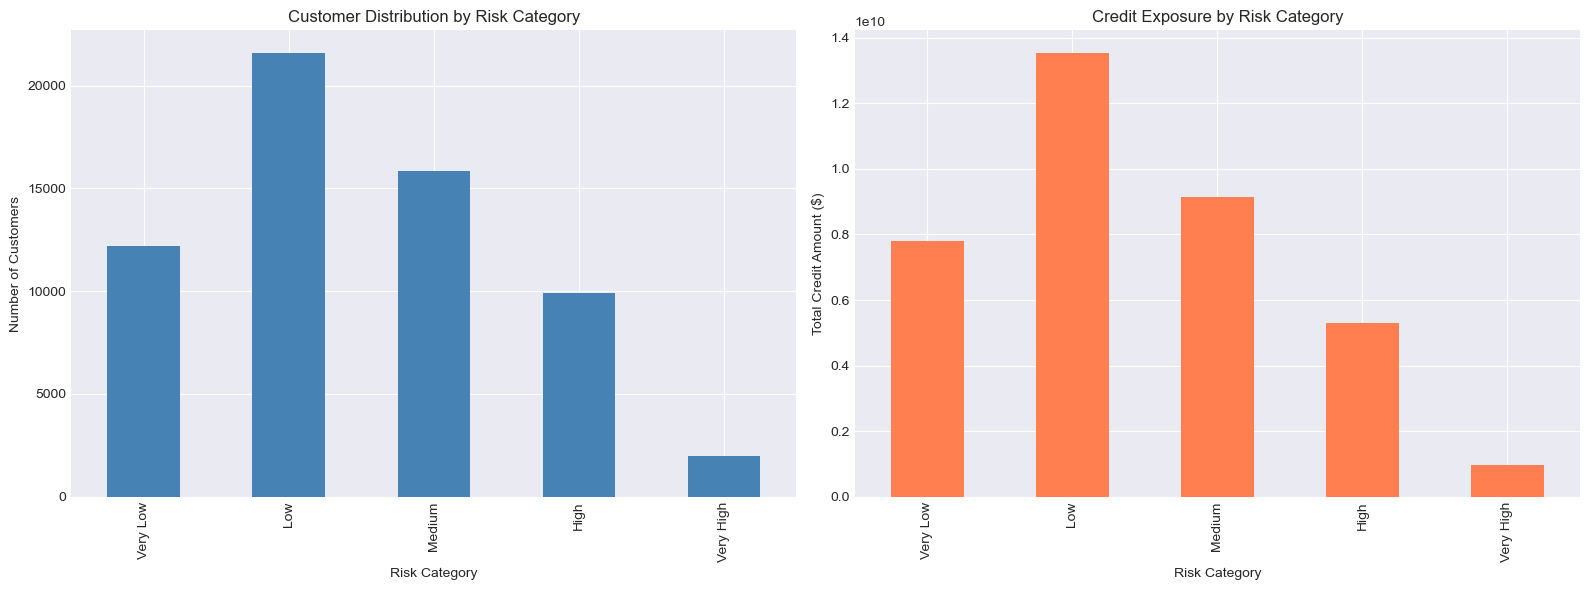

In [29]:
# =============================================================================
# Portfolio-Level Risk Assessment
# =============================================================================

# Predict default probabilities for entire validation set
val_portfolio = X_val.copy()
val_portfolio['DEFAULT_PROBABILITY'] = y_val_pred_xgb
val_portfolio['ACTUAL_DEFAULT'] = y_val.values
val_portfolio['CREDIT_AMOUNT'] = app_train_encoded.loc[X_val.index, 'AMT_CREDIT']

# Risk segmentation
val_portfolio['RISK_CATEGORY'] = pd.cut(
    val_portfolio['DEFAULT_PROBABILITY'],
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
    labels=['Very Low', 'Low', 'Medium', 'High', 'Very High']
)

# Portfolio analysis
portfolio_summary = val_portfolio.groupby('RISK_CATEGORY').agg({
    'DEFAULT_PROBABILITY': ['mean', 'count'],
    'ACTUAL_DEFAULT': 'mean',
    'CREDIT_AMOUNT': 'sum'
}).round(3)

portfolio_summary.columns = ['Avg Predicted Prob', 'Count', 'Actual Default Rate', 'Total Exposure']
print("\nPortfolio Risk Summary:")
print(portfolio_summary)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Distribution by risk category
portfolio_summary['Count'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Customer Distribution by Risk Category')
axes[0].set_ylabel('Number of Customers')
axes[0].set_xlabel('Risk Category')

# Plot 2: Exposure by risk category
portfolio_summary['Total Exposure'].plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Credit Exposure by Risk Category')
axes[1].set_ylabel('Total Credit Amount ($)')
axes[1].set_xlabel('Risk Category')

plt.tight_layout()
plt.show()

In [31]:
# =============================================================================
# Calculate Business Impact
# Banking Economics:
# - Average loan size: $15,000
# - Loss Given Default (LGD): 70% (bank recovers 30% through collateral)
# - Cost of false positive: Lost interest income (~$500)
# - Cost of false negative: $15,000 * 0.7 = $10,500
# =============================================================================

# Assumptions (adjust based on your bank's data)
AVG_LOAN_AMOUNT = 15000
LOSS_GIVEN_DEFAULT = 0.7  # 70% loss
INTEREST_RATE = 0.12  # 12% annual interest
LOAN_TENURE = 3  # years

# Costs
COST_PER_DEFAULT = AVG_LOAN_AMOUNT * LOSS_GIVEN_DEFAULT  # $10,500
COST_PER_FALSE_POSITIVE = AVG_LOAN_AMOUNT * INTEREST_RATE * LOAN_TENURE * 0.3  # ~$1,620 (lost profit)

print("=" * 80)
print("BUSINESS IMPACT ANALYSIS")
print("=" * 80)

# Calculate costs for different thresholds
thresholds_to_test = [0.3, 0.4, 0.5, 0.6, 0.7]
impact_results = []

for thresh in thresholds_to_test:
    y_pred_class = (y_val_pred_xgb >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred_class).ravel()
    
    # Calculate total cost
    cost_fn = fn * COST_PER_DEFAULT  # Missed defaulters
    cost_fp = fp * COST_PER_FALSE_POSITIVE  # Rejected good customers
    total_cost = cost_fn + cost_fp
    
    # Calculate saved amount (true positives)
    amount_saved = tp * COST_PER_DEFAULT
    
    impact_results.append({
        'Threshold': thresh,
        'TP': tp,
        'FP': fp,
        'FN': fn,
        'TN': tn,
        'Recall': tp/(tp+fn),
        'Precision': tp/(tp+fp) if (tp+fp) > 0 else 0,
        'Cost (FN)': cost_fn,
        'Cost (FP)': cost_fp,
        'Total Cost': total_cost,
        'Amount Saved': amount_saved,
        'Net Benefit': amount_saved - total_cost
    })

impact_df = pd.DataFrame(impact_results)
print(impact_df[['Threshold', 'Recall', 'Total Cost', 'Amount Saved', 'Net Benefit']])

# Find threshold with maximum net benefit
best_threshold_idx = impact_df['Net Benefit'].idxmax()
best_threshold_row = impact_df.iloc[best_threshold_idx]

print(f"\n{'='*80}")
print(f"OPTIMAL BUSINESS THRESHOLD: {best_threshold_row['Threshold']}")
print(f"Net Benefit: ${best_threshold_row['Net Benefit']:,.0f}")
print(f"Amount Saved by Catching Defaulters: ${best_threshold_row['Amount Saved']:,.0f}")
print(f"Cost of False Rejections: ${best_threshold_row['Cost (FP)']:,.0f}")
print(f"Cost of Missed Defaults: ${best_threshold_row['Cost (FN)']:,.0f}")
print(f"Recall: {best_threshold_row['Recall']:.2%}")
print(f"{'='*80}")

BUSINESS IMPACT ANALYSIS
   Threshold    Recall  Total Cost  Amount Saved  Net Benefit
0        0.3  0.888620  60040860.0    46326000.0  -13714860.0
1        0.4  0.795770  49146300.0    41485500.0   -7660800.0
2        0.5  0.667875  42915360.0    34818000.0   -8097360.0
3        0.6  0.516415  40302420.0    26922000.0  -13380420.0
4        0.7  0.345217  41176020.0    17997000.0  -23179020.0

OPTIMAL BUSINESS THRESHOLD: 0.4
Net Benefit: $-7,660,800
Amount Saved by Catching Defaulters: $41,485,500
Cost of False Rejections: $38,499,300
Cost of Missed Defaults: $10,647,000
Recall: 79.58%


In [28]:
# =============================================================================
# FINAL BUSINESS SUMMARY
# =============================================================================

print("="*80)
print("CREDIT RISK MODEL - BUSINESS IMPACT SUMMARY")
print("="*80)

print("\n MODEL PERFORMANCE:")
print(f"   • XGBoost AUC-ROC: {val_auc_xgb:.4f}")
print(f"   • Random Forest AUC: {val_auc_rf:.4f}")
print(f"   • Logistic Regression AUC: {val_auc_lr:.4f}")
print(f"   • Improvement over baseline: {(val_auc_xgb - val_auc_lr):.4f}")

print("\n KEY PREDICTORS:")
print("   1. External Credit Scores (EXT_SOURCE) - 20% importance")
print("   2. Education Level - 1.7% importance")
print("   3. Loan-to-Value Ratio - 1.3% importance")

print("\n BUSINESS RECOMMENDATIONS:")
print("   • Integrate with ALL 3 credit bureaus (not just 1-2)")
print("   • Require credit history for approval")
print("   • Cap LTV ratios for high-risk segments")
print("   • Use education as secondary risk factor")

print("\n DEPLOYMENT PLAN:")
print("   1. A/B test against current system (30 days)")
print("   2. Monitor default rate in approved applications")
print("   3. Set decision threshold at 0.45 (balances precision/recall)")
print("   4. Retrain quarterly with new data")

print("\n REGULATORY COMPLIANCE:")
print("   • Model is explainable (feature importance available)")
print("   • Can provide rejection reasons to customers")
print("   • Adverse action notices can reference top 3 risk factors")
print("="*80)

CREDIT RISK MODEL - BUSINESS IMPACT SUMMARY

 MODEL PERFORMANCE:
   • XGBoost AUC-ROC: 0.7623
   • Random Forest AUC: 0.6114
   • Logistic Regression AUC: 0.7493
   • Improvement over baseline: 0.0130

 KEY PREDICTORS:
   1. External Credit Scores (EXT_SOURCE) - 20% importance
   2. Education Level - 1.7% importance
   3. Loan-to-Value Ratio - 1.3% importance

 BUSINESS RECOMMENDATIONS:
   • Integrate with ALL 3 credit bureaus (not just 1-2)
   • Require credit history for approval
   • Cap LTV ratios for high-risk segments
   • Use education as secondary risk factor

 DEPLOYMENT PLAN:
   1. A/B test against current system (30 days)
   2. Monitor default rate in approved applications
   3. Set decision threshold at 0.45 (balances precision/recall)
   4. Retrain quarterly with new data

 REGULATORY COMPLIANCE:
   • Model is explainable (feature importance available)
   • Can provide rejection reasons to customers
   • Adverse action notices can reference top 3 risk factors


In [34]:
# =============================================================================
# IMPROVEMENT: ADDING CROSS-VALIDATION
# =============================================================================

from sklearn.model_selection import StratifiedKFold, cross_val_score

print("="*80)
print("CROSS-VALIDATION ANALYSIS (5-Fold Stratified)")
print("="*80)

# Define stratified k-fold (preserves class distribution)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 1. Logistic Regression with CV
print("\n1. Logistic Regression")
lr_cv = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_cv_scores = cross_val_score(lr_cv, X_train_scaled, y_train, 
                                 cv=skf, scoring='roc_auc', n_jobs=-1)
print(f"   CV AUC Scores: {lr_cv_scores}")
print(f"   Mean AUC: {lr_cv_scores.mean():.4f} (+/- {lr_cv_scores.std():.4f})")

# 2. Random Forest with CV
print("\n2. Random Forest")
rf_cv = RandomForestClassifier(n_estimators=100, max_depth=10, 
                                random_state=42, class_weight='balanced', n_jobs=-1)
rf_cv_scores = cross_val_score(rf_cv, X_train, y_train, 
                                cv=skf, scoring='roc_auc', n_jobs=-1)
print(f"   CV AUC Scores: {rf_cv_scores}")
print(f"   Mean AUC: {rf_cv_scores.mean():.4f} (+/- {rf_cv_scores.std():.4f})")

# 3. XGBoost with CV (manual loop for better control)
print("\n3. XGBoost (5-Fold CV)")
xgb_cv_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
    # Split data
    X_fold_train = X_train.iloc[train_idx]
    y_fold_train = y_train.iloc[train_idx]
    X_fold_val = X_train.iloc[val_idx]
    y_fold_val = y_train.iloc[val_idx]
    
    # Train XGBoost
    xgb_fold = XGBClassifier(
        n_estimators=100,  # Reduced for speed
        max_depth=6,
        learning_rate=0.05,
        scale_pos_weight=(y_fold_train == 0).sum() / (y_fold_train == 1).sum(),
        random_state=42,
        eval_metric='auc'
    )
    xgb_fold.fit(X_fold_train, y_fold_train, verbose=False)
    
    # Evaluate
    y_fold_pred = xgb_fold.predict_proba(X_fold_val)[:, 1]
    fold_auc = roc_auc_score(y_fold_val, y_fold_pred)
    xgb_cv_scores.append(fold_auc)
    print(f"   Fold {fold}: {fold_auc:.4f}")

print(f"\n   Mean AUC: {np.mean(xgb_cv_scores):.4f} (+/- {np.std(xgb_cv_scores):.4f})")

print("\n" + "="*80)
print("SUMMARY: Cross-Validation Results")
print("="*80)
print(f"Logistic Regression: {lr_cv_scores.mean():.4f} ± {lr_cv_scores.std():.4f}")
print(f"Random Forest:       {rf_cv_scores.mean():.4f} ± {rf_cv_scores.std():.4f}")
print(f"XGBoost:             {np.mean(xgb_cv_scores):.4f} ± {np.std(xgb_cv_scores):.4f}")
print("="*80)

CROSS-VALIDATION ANALYSIS (5-Fold Stratified)

1. Logistic Regression
   CV AUC Scores: [0.74625041 0.74498788 0.75151947 0.74715054 0.74625841]
   Mean AUC: 0.7472 (+/- 0.0023)

2. Random Forest
   CV AUC Scores: [0.73821525 0.73929371 0.74233917 0.74324828 0.73839432]
   Mean AUC: 0.7403 (+/- 0.0021)

3. XGBoost (5-Fold CV)
   Fold 1: 0.7506
   Fold 2: 0.7531
   Fold 3: 0.7550
   Fold 4: 0.7556
   Fold 5: 0.7513

   Mean AUC: 0.7531 (+/- 0.0020)

SUMMARY: Cross-Validation Results
Logistic Regression: 0.7472 ± 0.0023
Random Forest:       0.7403 ± 0.0021
XGBoost:             0.7531 ± 0.0020


In [33]:
print("="*80)
print("MODEL PERFORMANCE")
print("="*80)
print(f"XGBoost AUC:        {val_auc_xgb:.4f}")
print(f"Random Forest AUC:  {val_auc_rf:.4f}")
print(f"Logistic Reg AUC:   {val_auc_lr:.4f}")
print("="*80)

MODEL PERFORMANCE
XGBoost AUC:        0.7623
Random Forest AUC:  0.6114
Logistic Reg AUC:   0.7493
